# Prediction Ranking for Trajectron++

Trajectron++ birden fazla (N=20) gelecek trajektori öngörüyor. Bu notebook,
**ground truth olmadan** bu öngörüleri sıralamak için 4 farklı yöntem uygular.

**Yöntemler:**
1. **Mean Proximity** — Ortalama trajektoriye en yakın = en güvenilir
2. **KDE Consensus** — Örneklerin yoğun olduğu bölgedeki = en olası
3. **Endpoint Centrality** — Son noktası merkeze en yakın = en güvenilir
4. **Pairwise Distance** — Diğer tüm öngörülere en yakın = en temsili

Scaled pkl (`my_video_test_scaled.pkl`) kullanır.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.home() / "Trajectron-plus-plus"
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "trajectron"))

import dill
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from environment import Environment
from utils import prediction_output_to_trajectories
from model.model_registrar import ModelRegistrar
from model.online.online_trajectron import OnlineTrajectron

print("Imports OK")

Imports OK


In [2]:
# ===== VERİ ve MODEL YÜKLE =====
PROCESSED_DIR = PROJECT_ROOT / "experiments" / "processed"
with open(PROCESSED_DIR / "my_video_test_scaled.pkl", "rb") as f:
    eval_env = dill.load(f)
print(f"Scenes: {len(eval_env.scenes)}")

MODEL_DIR = PROJECT_ROOT / "experiments" / "pedestrians" / "models" / \
            "models_26_Dec_2025_14_50_24_eth_demo"
CHECKPOINT = 3

with open(MODEL_DIR / "config.json", "r") as f:
    hyperparams = json.load(f)
hyperparams["incl_robot_node"] = False
hyperparams["offline_scene_graph"] = True

model_registrar = ModelRegistrar(MODEL_DIR, device="cpu")
model_registrar.load_models(iter_num=CHECKPOINT)

online_traj = OnlineTrajectron(model_registrar, hyperparams, device="cpu")
print("Model ready")

Scenes: 1

Loading from /Users/simayyalcin/Trajectron-plus-plus/experiments/pedestrians/models/models_26_Dec_2025_14_50_24_eth_demo/model_registrar-3.pt
Loaded!

Model ready


/Users/simayyalcin/Trajectron-plus-plus/trajectron/model/model_registrar.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model_dict = torch.load(save_path, map_loc

In [3]:
# ===== PREDICTION =====
NUM_SAMPLES = 20

scene = eval_env.scenes[0]
max_hl = hyperparams["maximum_history_length"]
ph = hyperparams["prediction_horizon"]

latest_timestep = scene.timesteps - ph - 1
timestep = max_hl if max_hl <= latest_timestep else max(1, latest_timestep)

env = Environment(
    node_type_list=eval_env.node_type_list,
    standardization=eval_env.standardization,
    scenes=[scene],
    attention_radius=eval_env.attention_radius,
    robot_type=eval_env.robot_type
)
online_traj.set_environment(env, timestep)
input_dict = scene.get_clipped_input_dict(timestep, hyperparams["state"])

dists, preds = online_traj.incremental_forward(
    input_dict, maps=None,
    prediction_horizon=ph,
    num_samples=NUM_SAMPLES,
    full_dist=True
)

# prediction_output_to_trajectories ile history ve prediction çıkar
pred_dict, hist_dict, fut_dict = prediction_output_to_trajectories(
    {timestep: preds}, scene.dt, max_hl, ph, map=None
)
prediction_dict = pred_dict[timestep]
histories_dict = hist_dict[timestep]

print(f"timestep={timestep}, nodes={list(preds.keys())}")
for node in prediction_dict:
    print(f"  {node}: predictions shape={prediction_dict[node].shape}, history shape={histories_dict[node].shape}")

timestep=7, nodes=[PEDESTRIAN/0]
  PEDESTRIAN/0: predictions shape=(1, 20, 12, 2), history shape=(7, 2)


/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


In [4]:
# ===== RANKING FONKSİYONLARI =====

def rank_mean_proximity(predictions):
    """
    Yöntem 1: Ortalama trajektoriye yakınlık.
    Tüm N sample'ın ortalamasını al, her sample'ın bu ortalamaya
    olan mesafesini hesapla. En yakın = Rank 1.
    
    Mantık: Çoğu öngörünün uzlaştığı yön en güvenilirdir.
    """
    # predictions shape: (1, N, ph, 2)
    samples = predictions[0]          # (N, ph, 2)
    mean_traj = samples.mean(axis=0)  # (ph, 2)
    
    distances = []
    for s in range(samples.shape[0]):
        d = np.sqrt(((samples[s] - mean_traj) ** 2).sum(axis=1)).mean()
        distances.append(d)
    
    distances = np.array(distances)
    order = np.argsort(distances)  # küçük mesafe = yüksek rank
    return {"scores": -distances, "order": order, "mean_traj": mean_traj}


def rank_kde_consensus(predictions):
    """
    Yöntem 2: KDE (Kernel Density Estimation) tabanlı konsensüs.
    Her timestep'te tüm sample pozisyonlarına KDE fit et,
    her sample'ın toplam log-yoğunluğunu hesapla. Yüksek = Rank 1.
    
    Mantık: Diğer sample'ların yoğun olduğu bölgedeki trajektori daha olası.
    """
    from scipy.stats import gaussian_kde
    
    samples = predictions[0]  # (N, ph, 2)
    N, ph_len, _ = samples.shape
    log_densities = np.zeros(N)
    
    for t in range(ph_len):
        points = samples[:, t, :]  # (N, 2)
        # KDE fit etmek için yeterli varyans lazım
        if np.std(points[:, 0]) < 1e-8 and np.std(points[:, 1]) < 1e-8:
            continue
        try:
            kde = gaussian_kde(points.T)
            log_densities += np.log(kde(points.T) + 1e-300)
        except np.linalg.LinAlgError:
            continue
    
    order = np.argsort(log_densities)[::-1]  # yüksek yoğunluk = yüksek rank
    return {"scores": log_densities, "order": order}


def rank_endpoint_centrality(predictions):
    """
    Yöntem 3: Son nokta merkeziliği.
    Tüm sample'ların son pozisyonlarının merkezini (centroid) al,
    her sample'ın son noktasının bu merkeze mesafesini hesapla.
    
    Mantık: Son noktası en "merkezi" olan öngörü en güvenilir.
    Bu FDE (Final Displacement Error) ile doğrudan ilişkili.
    """
    samples = predictions[0]              # (N, ph, 2)
    endpoints = samples[:, -1, :]          # (N, 2)
    centroid = endpoints.mean(axis=0)      # (2,)
    
    distances = np.sqrt(((endpoints - centroid) ** 2).sum(axis=1))
    order = np.argsort(distances)  # küçük mesafe = yüksek rank
    return {"scores": -distances, "order": order, "centroid": centroid}


def rank_pairwise_distance(predictions):
    """
    Yöntem 4: Çiftler arası ortalama mesafe.
    Her sample için, diğer TÜM sample'lara olan ortalama mesafeyi hesapla.
    En düşük ortalama mesafe = en "temsilci" trajektori = Rank 1.
    
    Mantık: Geometric median'a en yakın trajektori, öngörü kümesinin
    en iyi temsilcisidir.
    """
    samples = predictions[0]  # (N, ph, 2)
    N = samples.shape[0]
    avg_dists = np.zeros(N)
    
    for i in range(N):
        total = 0.0
        for j in range(N):
            if i != j:
                d = np.sqrt(((samples[i] - samples[j]) ** 2).sum(axis=1)).mean()
                total += d
        avg_dists[i] = total / (N - 1)
    
    order = np.argsort(avg_dists)  # küçük = yüksek rank
    return {"scores": -avg_dists, "order": order}


print("Ranking functions defined")

Ranking functions defined


In [5]:
# ===== RANK HESAPLA =====
rankings = {}
method_names = {
    "mean_prox": "Mean Proximity",
    "kde":       "KDE Consensus",
    "endpoint":  "Endpoint Centrality",
    "pairwise":  "Pairwise Distance",
}

for node in prediction_dict:
    p = prediction_dict[node]  # (1, N, ph, 2)
    rankings[node] = {
        "mean_prox": rank_mean_proximity(p),
        "kde":       rank_kde_consensus(p),
        "endpoint":  rank_endpoint_centrality(p),
        "pairwise":  rank_pairwise_distance(p),
    }

# Sonuçları yazdır
for node in rankings:
    print(f"\n{'='*60}")
    print(f"Node: {node}")
    print(f"{'='*60}")
    for method_key, method_label in method_names.items():
        r = rankings[node][method_key]
        top3 = r["order"][:3]
        print(f"\n  {method_label}:")
        print(f"    Rank 1: sample #{top3[0]} (score: {r['scores'][top3[0]]:.4f})")
        print(f"    Rank 2: sample #{top3[1]} (score: {r['scores'][top3[1]]:.4f})")
        print(f"    Rank 3: sample #{top3[2]} (score: {r['scores'][top3[2]]:.4f})")
    
    # Yöntemler arası karşılaştırma
    print(f"\n  --- Rank #1 karşılaştırması ---")
    for method_key, method_label in method_names.items():
        r1 = rankings[node][method_key]["order"][0]
        print(f"    {method_label:25s} → sample #{r1}")


Node: PEDESTRIAN/0

  Mean Proximity:
    Rank 1: sample #10 (score: -0.0212)
    Rank 2: sample #6 (score: -0.0254)
    Rank 3: sample #19 (score: -0.0276)

  KDE Consensus:
    Rank 1: sample #6 (score: 55.3693)
    Rank 2: sample #10 (score: 54.7695)
    Rank 3: sample #12 (score: 54.5468)

  Endpoint Centrality:
    Rank 1: sample #15 (score: -0.0219)
    Rank 2: sample #18 (score: -0.0257)
    Rank 3: sample #11 (score: -0.0258)

  Pairwise Distance:
    Rank 1: sample #10 (score: -0.0503)
    Rank 2: sample #6 (score: -0.0513)
    Rank 3: sample #19 (score: -0.0519)

  --- Rank #1 karşılaştırması ---
    Mean Proximity            → sample #10
    KDE Consensus             → sample #6
    Endpoint Centrality       → sample #15
    Pairwise Distance         → sample #10


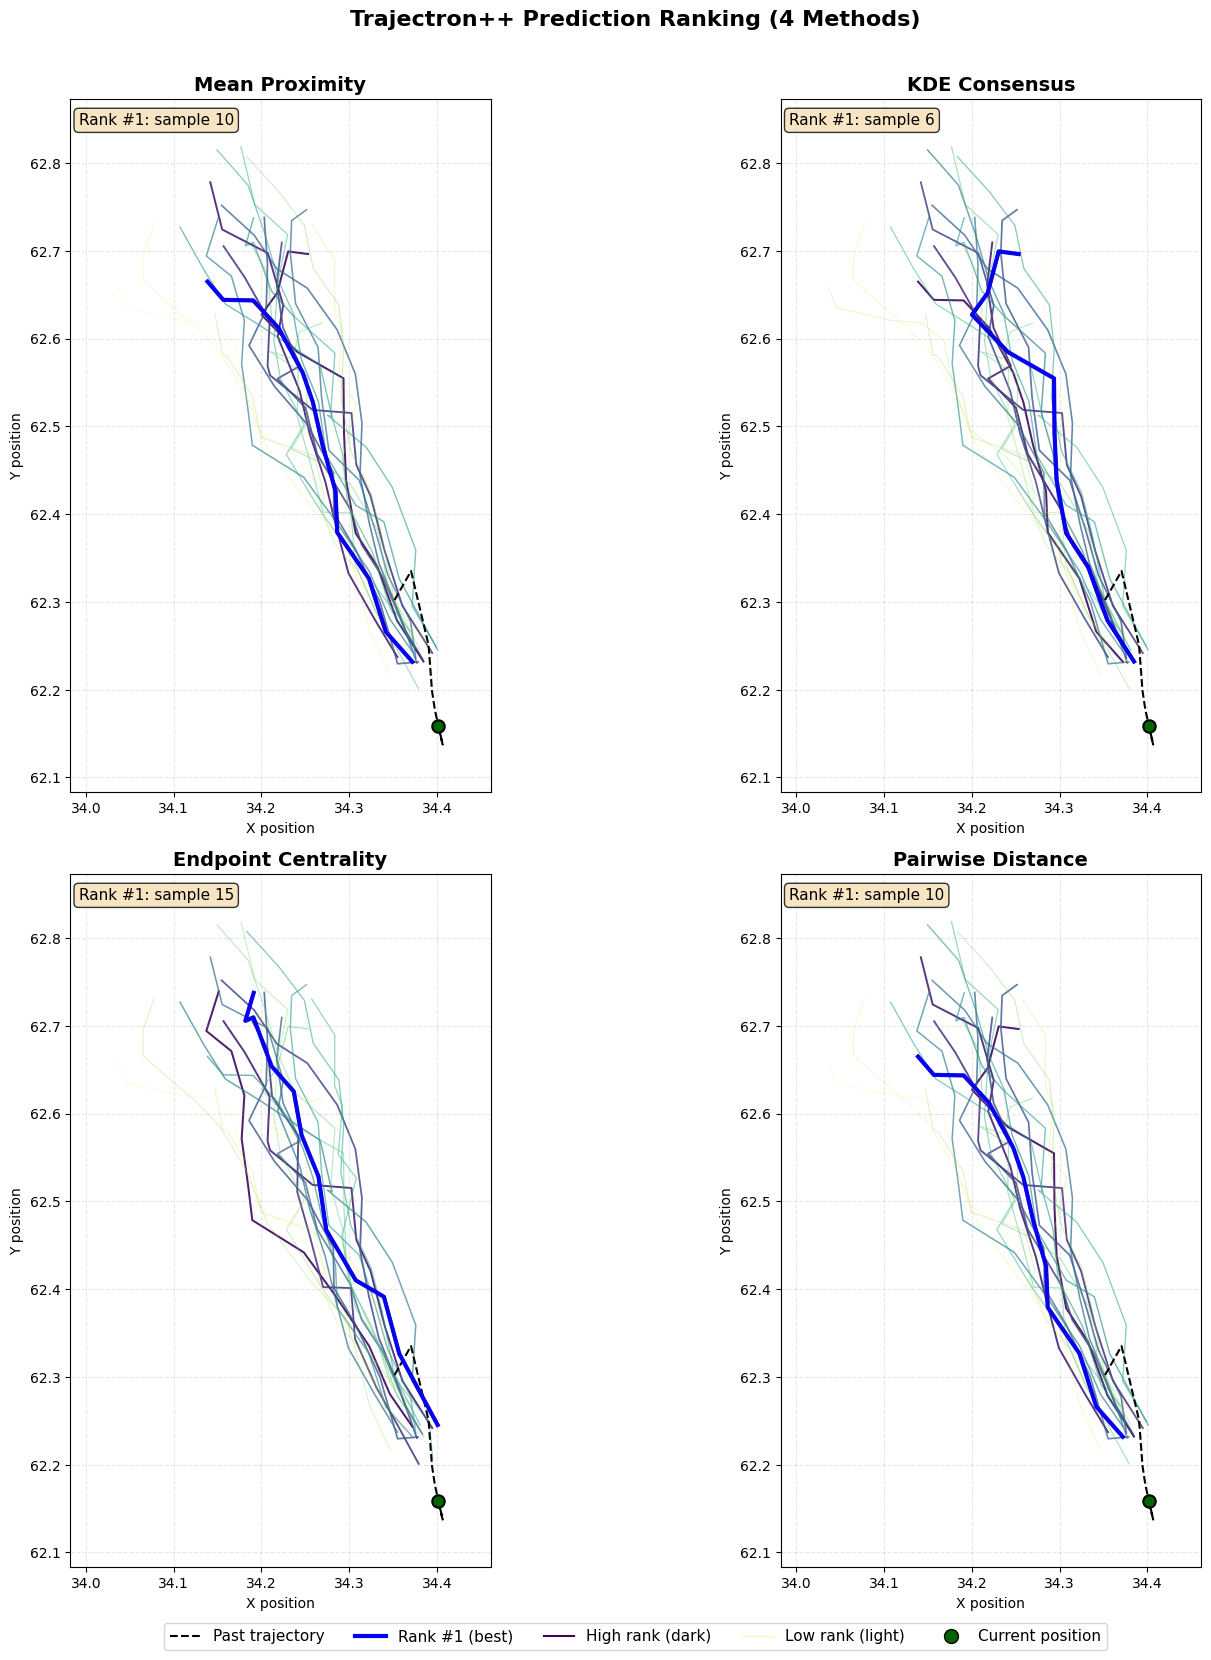

In [6]:
# ===== 4 YÖNTEM İÇİN TEK GÖRSELLEŞTİRME =====

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()
cmap = plt.cm.viridis

for idx, (method_key, method_label) in enumerate(method_names.items()):
    ax = axes[idx]
    xs, ys = [], []
    
    for node in prediction_dict:
        history = histories_dict[node]
        predictions = prediction_dict[node]  # (1, N, ph, 2)
        r = rankings[node][method_key]
        order = r["order"]
        N = len(order)
        
        if np.isnan(history[-1]).any():
            continue
        
        # Past trajectory
        ax.plot(history[:, 0], history[:, 1], 'k--', linewidth=1.5, zorder=2)
        xs.append(history[:, 0]); ys.append(history[:, 1])
        
        # Tüm sample'lar (renk = rank sırası)
        for rank_pos, sample_idx in enumerate(order):
            alpha = max(0.15, 1.0 - 0.8 * (rank_pos / max(N - 1, 1)))
            lw = 2.5 if rank_pos == 0 else max(0.5, 1.5 - rank_pos * 0.05)
            color = cmap(rank_pos / max(N - 1, 1))
            traj = predictions[0, sample_idx]
            ax.plot(traj[:, 0], traj[:, 1], color=color, alpha=alpha,
                    linewidth=lw, zorder=3 if rank_pos == 0 else 1)
            xs.append(traj[:, 0]); ys.append(traj[:, 1])
        
        # Rank #1 üstüne mavi kalın çiz
        best = predictions[0, order[0]]
        ax.plot(best[:, 0], best[:, 1], 'b-', linewidth=3.0, alpha=0.9, zorder=5)
        
        # Mevcut pozisyon
        ax.scatter(history[-1, 0], history[-1, 1], s=80, color="darkgreen",
                   edgecolors="black", linewidth=1.5, zorder=6)
    
    # Axis ayarları
    if xs:
        x_all = np.concatenate(xs)
        y_all = np.concatenate(ys)
        mask = ~np.isnan(x_all) & ~np.isnan(y_all)
        if mask.any():
            span = max(x_all[mask].ptp(), y_all[mask].ptp(), 1e-6)
            pad = 0.08 * span
            ax.set_xlim(x_all[mask].min() - pad, x_all[mask].max() + pad)
            ax.set_ylim(y_all[mask].min() - pad, y_all[mask].max() + pad)
    
    ax.set_title(method_label, fontsize=14, fontweight='bold')
    ax.set_xlabel("X position")
    ax.set_ylabel("Y position")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linestyle="--", alpha=0.3)
    
    # Rank #1 sample numarasını belirt
    for node in prediction_dict:
        r1 = rankings[node][method_key]["order"][0]
        ax.text(0.02, 0.98, f"Rank #1: sample {r1}",
                transform=ax.transAxes, fontsize=11, va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Ortak legend
legend_elements = [
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Past trajectory"),
    Line2D([0], [0], color="blue", linewidth=3.0, label="Rank #1 (best)"),
    Line2D([0], [0], color=cmap(0.0), linewidth=1.5, label="High rank (dark)"),
    Line2D([0], [0], color=cmap(1.0), linewidth=1.0, alpha=0.3, label="Low rank (light)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="darkgreen",
           markeredgecolor="black", markersize=10, label="Current position"),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Trajectron++ Prediction Ranking (4 Methods)", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# ===== KARŞILAŞTIRMA TABLOSU =====
print("\n" + "="*80)
print("RANKING KARŞILAŞTIRMASI: Her yöntemin Top-5 sample sıralaması")
print("="*80)

for node in rankings:
    print(f"\nNode: {node}")
    print(f"{'Method':<25s} | {'#1':>4s} {'#2':>4s} {'#3':>4s} {'#4':>4s} {'#5':>4s}")
    print("-" * 55)
    for method_key, method_label in method_names.items():
        order = rankings[node][method_key]["order"]
        top5 = order[:5]
        print(f"{method_label:<25s} | {top5[0]:>4d} {top5[1]:>4d} {top5[2]:>4d} {top5[3]:>4d} {top5[4]:>4d}")
    
    # Konsensüs: 4 yöntemde en sık top-3'te olan sample
    from collections import Counter
    top3_counter = Counter()
    for method_key in method_names:
        for s in rankings[node][method_key]["order"][:3]:
            top3_counter[s] += 1
    
    most_common = top3_counter.most_common(3)
    print(f"\n  Konsensüs (en çok top-3'te olan sample'lar):")
    for sample_id, count in most_common:
        print(f"    Sample #{sample_id}: {count}/4 yöntemde top-3")


RANKING KARŞILAŞTIRMASI: Her yöntemin Top-5 sample sıralaması

Node: PEDESTRIAN/0
Method                    |   #1   #2   #3   #4   #5
-------------------------------------------------------
Mean Proximity            |   10    6   19   11   12
KDE Consensus             |    6   10   12   11   19
Endpoint Centrality       |   15   18   11    1    8
Pairwise Distance         |   10    6   19   11   12

  Konsensüs (en çok top-3'te olan sample'lar):
    Sample #10: 3/4 yöntemde top-3
    Sample #6: 3/4 yöntemde top-3
    Sample #19: 2/4 yöntemde top-3


PEDESTRIAN/0: Consensus Rank #1=sample 10, #2=sample 11, #3=sample 19
  Average rank scores: [2.5  2.75 3.75 3.75 4.  ]


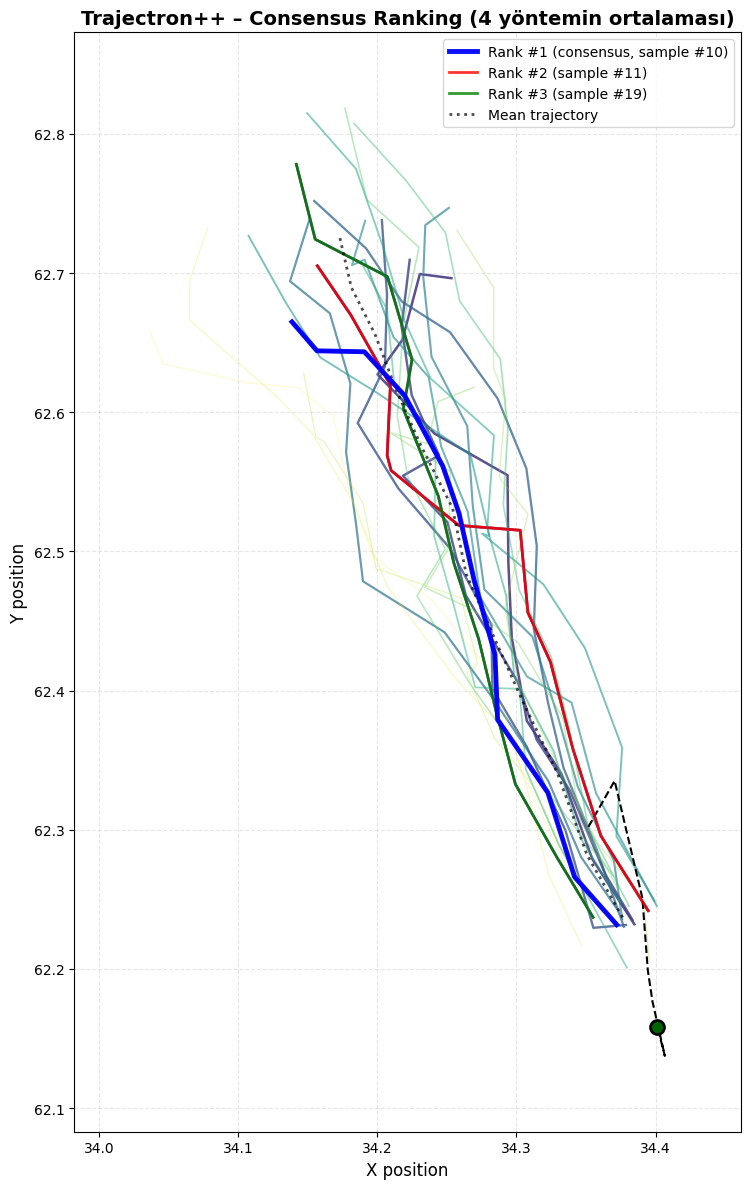

In [8]:
# ===== EN İYİ TEKLİ PLOT: Konsensüs Rank =====
# 4 yöntemin ortalamasına göre nihai ranking

fig, ax = plt.subplots(figsize=(12, 12))

for node in prediction_dict:
    history = histories_dict[node]
    predictions = prediction_dict[node]
    N = predictions.shape[1]
    
    # Her sample için 4 yöntemdeki rank sırasını ortala
    avg_rank = np.zeros(N)
    for method_key in method_names:
        order = rankings[node][method_key]["order"]
        for rank_pos, sample_idx in enumerate(order):
            avg_rank[sample_idx] += rank_pos
    avg_rank /= len(method_names)
    
    consensus_order = np.argsort(avg_rank).astype(int)
    
    if np.isnan(history[-1]).any():
        continue
    
    xs, ys = [], []
    
    # Past
    ax.plot(history[:, 0], history[:, 1], 'k--', linewidth=1.5, zorder=2)
    xs.append(history[:, 0]); ys.append(history[:, 1])
    
    # Tüm samples
    for rank_pos, sample_idx in enumerate(consensus_order):
        alpha = max(0.15, 1.0 - 0.8 * (rank_pos / max(N - 1, 1)))
        lw = max(0.5, 2.0 - rank_pos * 0.06)
        color = cmap(rank_pos / max(N - 1, 1))
        traj = predictions[0, sample_idx]
        ax.plot(traj[:, 0], traj[:, 1], color=color, alpha=alpha, linewidth=lw, zorder=1)
        xs.append(traj[:, 0]); ys.append(traj[:, 1])
    
    # Rank #1 (consensus)
    best_idx = consensus_order[0]
    best_traj = predictions[0, best_idx]
    ax.plot(best_traj[:, 0], best_traj[:, 1], 'b-', linewidth=3.5, alpha=0.95, zorder=5,
            label=f"Rank #1 (consensus, sample #{best_idx})")
    
    # Rank #2, #3
    for top_rank in [1, 2]:
        si = consensus_order[top_rank]
        t = predictions[0, si]
        style = 'r-' if top_rank == 1 else 'g-'
        ax.plot(t[:, 0], t[:, 1], style, linewidth=2.0, alpha=0.8, zorder=4,
                label=f"Rank #{top_rank+1} (sample #{si})")
    
    # Mean trajectory
    mean_traj = predictions[0].mean(axis=0)
    ax.plot(mean_traj[:, 0], mean_traj[:, 1], 'k:', linewidth=2.0, alpha=0.7, zorder=4,
            label="Mean trajectory")
    
    # Current position
    ax.scatter(history[-1, 0], history[-1, 1], s=100, color="darkgreen",
               edgecolors="black", linewidth=2, zorder=6)
    
    # Rank bilgisi
    print(f"{node}: Consensus Rank #1=sample {best_idx}, "
          f"#2=sample {consensus_order[1]}, #3=sample {consensus_order[2]}")
    print(f"  Average rank scores: {avg_rank[consensus_order[:5]]}")

# Axis
if xs:
    x_all = np.concatenate(xs)
    y_all = np.concatenate(ys)
    mask = ~np.isnan(x_all) & ~np.isnan(y_all)
    if mask.any():
        span = max(x_all[mask].ptp(), y_all[mask].ptp(), 1e-6)
        pad = 0.08 * span
        ax.set_xlim(x_all[mask].min() - pad, x_all[mask].max() + pad)
        ax.set_ylim(y_all[mask].min() - pad, y_all[mask].max() + pad)

ax.set_xlabel("X position", fontsize=12)
ax.set_ylabel("Y position", fontsize=12)
ax.set_title("Trajectron++ – Consensus Ranking (4 yöntemin ortalaması)", fontsize=14, fontweight='bold')
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(loc="upper right", fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

## Yöntemler Hakkında

| Yöntem | Mantık | Ne zaman en iyi? |
|--------|--------|-------------------|
| **Mean Proximity** | Ortalama trajektoriye en yakın sample en güvenilir | Unimodal (tek yönlü) senaryolar |
| **KDE Consensus** | Sample yoğunluğu yüksek bölgedeki trajektori daha olası | Multimodal senaryolarda yoğun kümeyi yakalar |
| **Endpoint Centrality** | Son noktası merkeze en yakın olan en güvenilir | FDE odaklı değerlendirme |
| **Pairwise Distance** | Diğer tüm sample'lara en yakın olan en temsili | Genel amaçlı, geometric median'a yakın |

**Konsensüs ranking**: 4 yöntemin ortalaması — en güvenilir sonuç.

### Neden GMM log-likelihood kullanmıyoruz?
`full_dist=True` ile Trajectron++ 20 farklı latent z'den 20 farklı GMM dağılımı üretiyor.
Öngörülen trajektoriler bu GMM'lerden sample'lanıyor ama her sample farklı bir GMM'den geliyor.
Dolayısıyla tek bir GMM altında tüm sample'ları değerlendirmek matematiksel olarak yanlış ve hep `-inf` veriyor.

Yukarıdaki 4 yöntem ise tamamen **sample tabanlı** — GMM parametrelerine bağımlı değil,
sadece öngörülen trajektorilerin kendilerine bakıyor.